In [1]:
import pandas as pd

train = pd.read_csv("churn-bigml-80.csv")
test = pd.read_csv("churn-bigml-20.csv")

train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
X_train = train.drop("Churn", axis=1)
y_train = train["Churn"]

X_test = test.drop("Churn", axis=1)
y_test = test["Churn"]

In [4]:
train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
train = train.drop("State", axis=1)
test = test.drop("State", axis=1)

In [6]:
train["International plan"] = train["International plan"].map({"Yes":1,"No":0})
train["Voice mail plan"] = train["Voice mail plan"].map({"Yes":1,"No":0})

test["International plan"] = test["International plan"].map({"Yes":1,"No":0})
test["Voice mail plan"] = test["Voice mail plan"].map({"Yes":1,"No":0})

In [7]:
train["Churn"] = train["Churn"].map({True:1, False:0})
test["Churn"] = test["Churn"].map({True:1, False:0})

In [8]:
X_train = train.drop("Churn", axis=1)
y_train = train["Churn"]

X_test = test.drop("Churn", axis=1)
y_test = test["Churn"]

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9550224887556222


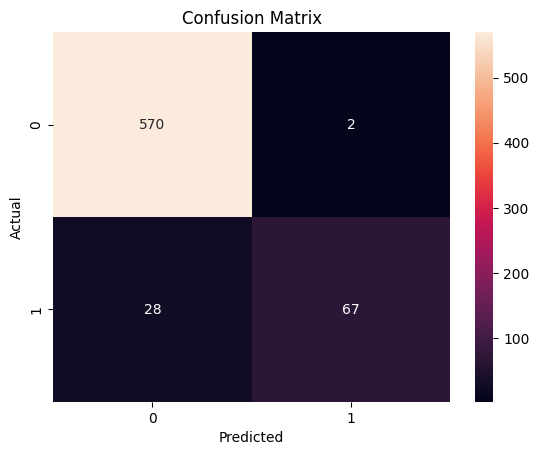

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
import pandas as pd

importance = model.feature_importances_

features = X_train.columns

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

df_imp = df_imp.sort_values(by="Importance", ascending=False)

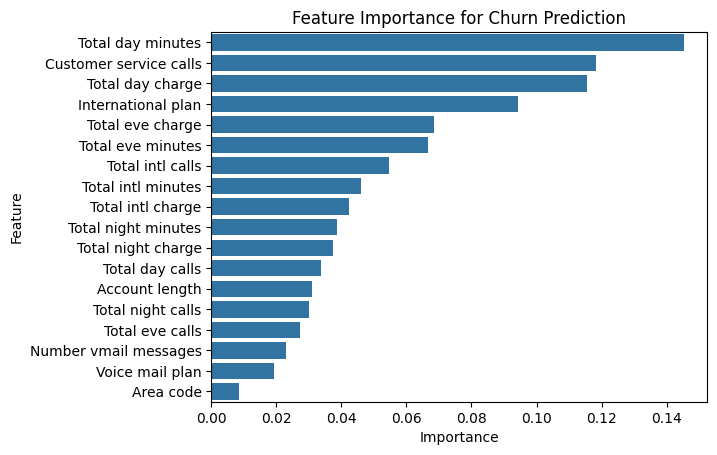

In [14]:
sns.barplot(x="Importance", y="Feature", data=df_imp)

plt.title("Feature Importance for Churn Prediction")

plt.show()

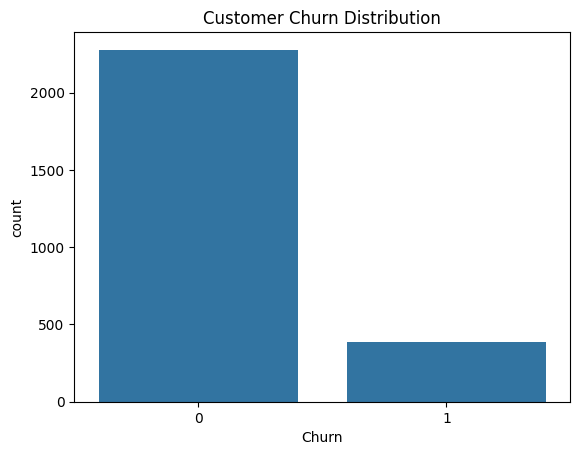

In [15]:
sns.countplot(x=train["Churn"])

plt.title("Customer Churn Distribution")

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       572
           1       0.97      0.71      0.82        95

    accuracy                           0.96       667
   macro avg       0.96      0.85      0.90       667
weighted avg       0.96      0.96      0.95       667

